## 2장 1강: 선형 회귀 모델과 오차 평가지표
### 3. 주택 가격 예측 선형 회귀 구현
#### 3.1 데이터 불러오기 및 확인

USA 주택 데이터(CSV) 불러오기

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('usa_housing.csv')
df.head()

,Price,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,LotSize,ZipCode,CrimeRate,SchoolRating
0,221958,1,1.9,4827,1979,2,1.45,82240,48.60,5
1,771155,2,2.0,1035,1987,2,1.75,74315,92.03,9
2,231932,1,3.0,2769,1982,1,1.46,79249,52.08,3
3,465838,3,3.3,2708,1907,3,1.62,80587,61.65,1
4,359178,4,3.4,1175,1994,2,0.74,20756,15.66,4


데이터 전처리: 최근 데이터 + 범죄율이 낮은 데이터로 필터링

In [6]:
df = df[(df['YearBuilt'] > 2015) & (df['CrimeRate'] < 40)]


그래프로 데이터 분포 확인하기

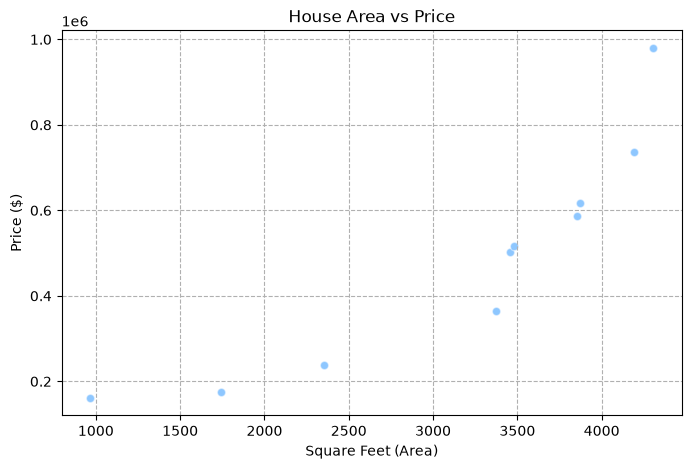

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(df['SquareFeet'], df['Price'], color='dodgerblue', alpha=0.5, edgecolor='w')
plt.title('House Area vs Price')
plt.xlabel('Square Feet (Area)')
plt.ylabel('Price ($)')
plt.grid(True, linestyle='--')
plt.show()

#### 3.2 모델 학습 및 결과 시각화

특성(Feature, 방 면적)과 정답(Label, 집값) 나누기

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error


X = df[['SquareFeet']].values
y = df['Price'].values

X.shape, y.shape

((10, 1), (10,))

선형 회귀 모델 준비 및 학습(fit)

- fit(특성, 정답(레이블)) : 학습 진행

In [21]:
model = LinearRegression()
model.fit(X, y)

model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[210.23]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.766e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[3328.98]


학습된 모델로 집값 예측해보기

In [19]:
# predict(..) : 예측

y_pred = model.predict(X)

y_pred

array([704505.64035344, 633657.39794181, 637441.57706172, 728892.57245951,
        26086.41702314, 189857.28004585, 318519.37012275, 532535.72257092,
       550195.22513049, 555240.79729037])

오차 점수 확인하기

In [20]:
mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)

print("MSE : ", mse)
print('MAE : ', mae)

MSE :  12374713026.514887
MAE :  83721.47403278269


모델이 찾은 직선 그래프로 그려보기

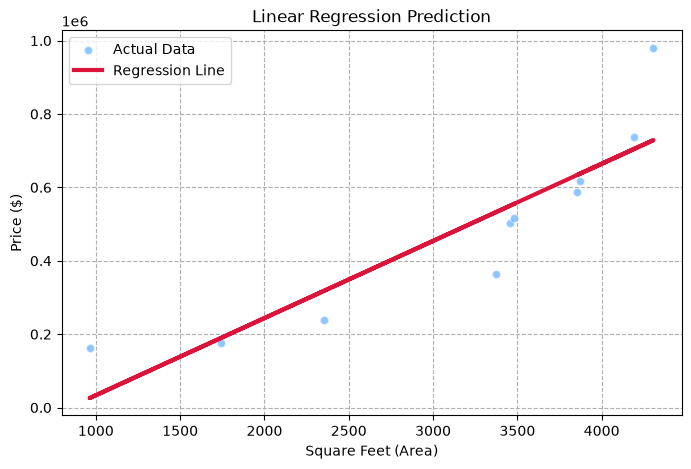

In [22]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='dodgerblue', alpha=0.5, edgecolor='w', label='Actual Data')
plt.plot(X, y_pred, color='crimson', linewidth=3, label='Regression Line')
plt.title('Linear Regression Prediction')
plt.xlabel('Square Feet (Area)')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()